In [17]:
# TechyJaunt Python Assignment.
import pandas as pd

In [18]:
# Codes used to load the dataset into Python
orders = pd.read_csv(r"C:\Users\damid\Downloads\project_orders_clean.csv")
products = pd.read_csv(r"C:\Users\damid\Downloads\project_products_clean.csv")
customers = pd.read_csv(r"C:\Users\damid\Downloads\project_customers_clean.csv")

In [19]:
# Exploratory Data Analysis
orders.head(8)

,order_id,customer_id,product_id,order_date,quantity,discount_pct,sales_channel,payment_method,total_amount
0,1,454,65,2025-11-15,3,0,STORE,CARD,30000
1,2,112,26,2026-02-17,10,0,ONLINE,USSD,150000
2,3,288,88,2026-02-02,10,0,STORE,CARD,25000
3,4,269,95,2025-08-14,6,0,STORE,USSD,45000
4,5,189,50,2024-10-17,1,0,ONLINE,TRANSFER,15000
5,6,227,83,2025-09-12,1,15,ONLINE,TRANSFER,4250
6,7,105,69,2026-03-14,4,15,ONLINE,TRANSFER,8500
7,8,291,7,2024-09-26,9,0,STORE,CARD,225000


In [23]:
# Exploratory Data Analysis
customers.head(3)

,customer_id,customer_name,city,customer_segment,signup_date,email
0,1,CATHY BARKER,ENUGU,RETAIL,2024-09-22,mwilkerson@example.com
1,2,NICHOLAS SCOTT,ABUJA,RETAIL,2023-11-22,andrewbenson@example.com
2,3,KAREN GLOVER,LAGOS,RETAIL,2026-01-16,ohenry@example.com


In [24]:
# Exploratory Data Analysis
products.head(3)

,product_id,product_name,category,unit_price
0,1,Product_1,GROCERIES,10000
1,2,Product_2,GROCERIES,10000
2,3,Product_3,HOME APPLIANCES,7500


In [25]:
# Code to Calculate Total Revenue
total_revenue = int(orders["total_amount"].sum())

print("Total Revenue =", total_revenue)

Total Revenue = 150209625


In [26]:
# Code to Find the Average Order Value (AOV)
aov = int(orders["total_amount"].mean())

print("Average Order Volume =", aov)

Average Order Volume = 75104


In [39]:
# Code to Identify the Top 10 Products by Revenue.
top_products_rev = (
    orders.merge(products, on = "product_id")
    .groupby(["product_name"])["total_amount"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
    .rename("Top Products")
)

print(top_products_rev)

product_name
Product_36    6347500
Product_85    6200000
Product_55    5990000
Product_14    5502500
Product_81    5182500
Product_31    5112500
Product_89    4855000
Product_75    4177500
Product_33    3850000
Product_92    3675000
Name: Top Products, dtype: int64


In [28]:
# Code to Identify the Highest Revenue Category.
top_category = (
    orders.merge(products, on = "product_id")
    .groupby("category")["total_amount"]
    .sum()
    .sort_values(ascending = False)
    .head(5)
    .rename("Top Category")
)

print(top_category)

category
GROCERIES          38685000
BEAUTY             35581375
ELECTRONICS        26518750
HOME APPLIANCES    26314375
FASHION            23110125
Name: Top Category, dtype: int64


In [29]:
# Code to Find the Best-Performing Region.
top_region = (
    orders.merge(customers, on = "customer_id")
    .groupby("city")["total_amount"]
    .sum()
    .sort_values(ascending = False)
    .head(10)
    .rename("Best Region")
)

print(top_region)

city
KANO             24377625
PORT HARCOURT    22200125
ABUJA            21923000
IBADAN           21669125
LAGOS            18495250
BENIN            17759250
ENUGU            16590500
Name: Best Region, dtype: int64


In [30]:
# Code to Find the Most Used Payment Method.
top_payment = (
    orders.groupby("payment_method")["order_id"].count()
    .sort_values(ascending = False)
    .rename("Top Payment Method")
)

print(top_payment)

payment_method
TRANSFER    521
CASH        511
USSD        500
CARD        468
Name: Top Payment Method, dtype: int64


In [31]:
# Code to check the data type of the order date column
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   order_id        2000 non-null   int64 
 1   customer_id     2000 non-null   int64 
 2   product_id      2000 non-null   int64 
 3   order_date      2000 non-null   object
 4   quantity        2000 non-null   int64 
 5   discount_pct    2000 non-null   int64 
 6   sales_channel   2000 non-null   object
 7   payment_method  2000 non-null   object
 8   total_amount    2000 non-null   int64 
dtypes: int64(6), object(3)
memory usage: 140.8+ KB


In [32]:
# Code to change the data type of the order date column
orders["order_date"] = pd.to_datetime(orders["order_date"])

In [33]:
# Code to validate the change
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        2000 non-null   int64         
 1   customer_id     2000 non-null   int64         
 2   product_id      2000 non-null   int64         
 3   order_date      2000 non-null   datetime64[ns]
 4   quantity        2000 non-null   int64         
 5   discount_pct    2000 non-null   int64         
 6   sales_channel   2000 non-null   object        
 7   payment_method  2000 non-null   object        
 8   total_amount    2000 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(2)
memory usage: 140.8+ KB


In [34]:
# Code to Identify the Month with the Highest Sales.
orders["month"] = orders["order_date"].dt.month_name()

monthly_sales = (
    orders.groupby("month")["total_amount"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .rename("Top Month")
)

print(monthly_sales)

month
July         14516000
September    14149250
August       13921750
May          13553000
January      13508750
Name: Top Month, dtype: int64


In [35]:
# Code to Find the Customer with the Most Orders.
top_customer_order = (
    orders.merge(customers, on = "customer_id")
    .groupby("customer_name")["order_id"]
    .count()
    .sort_values(ascending = False)
    .head(1)
    .rename("Top Customer Order Count")
)

print(top_customer_order)

customer_name
GLENN BOLTON    11
Name: Top Customer Order Count, dtype: int64


In [36]:
# Code to Identify the Top 5 Customers by Revenue.
top_customer = (
    orders.merge(customers, on = "customer_id")
    .groupby("customer_name")["total_amount"]
    .sum()
    .sort_values(ascending = False)
    .head(5)
    .rename("Top Customer")
)

print(top_customer)

customer_name
KENNETH OLSON        1631750
CATHERINE NAVARRO    1254750
GLENN BOLTON         1044500
MARGARET BROWN       1008750
LESLIE SHEA           995000
Name: Top Customer, dtype: int64


In [40]:
# Codes Used to Import Visualization Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

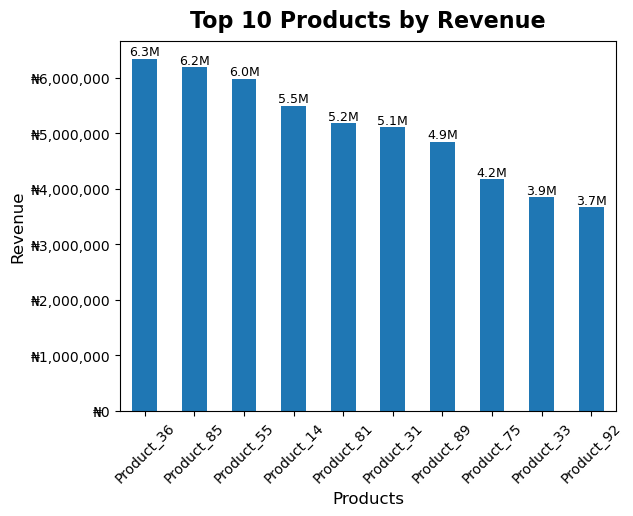

In [41]:
# Code used to show the top 10 products by revenue
bars = top_products_rev.plot(kind = "bar")
for bar in bars.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{height/1e6:.1f}M',
              ha="center", va="bottom", fontsize=9)

plt.title("Top 10 Products by Revenue", fontsize = 16, fontweight = "bold", pad = 10)
plt.xlabel("Products", fontsize = 12)
plt.xticks(rotation = 45)
plt.ylabel("Revenue", fontsize = 12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₦{x:,.0f}'))
plt.show()

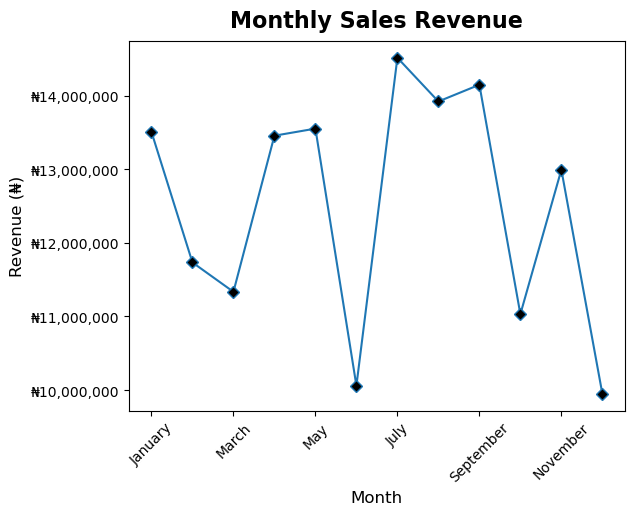

In [43]:
# Code to show the Monthly Sales Trend
monthly_sales_rev = (
    orders.groupby(orders["order_date"].dt.month)["total_amount"]
    .sum()
)

monthly_sales_rev.index = pd.to_datetime(monthly_sales_rev.index, format="%m").strftime("%B")

monthly_sales_rev.plot(kind = "line", marker = "D", markerfacecolor = "Black")
plt.title("Monthly Sales Revenue", fontsize = 16, fontweight = "bold", pad = 10)
plt.xlabel("Month", fontsize = 12)
plt.xticks(rotation = 45)
plt.ylabel("Revenue (₦)", fontsize = 12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'₦{x:,.0f}'))
plt.show()

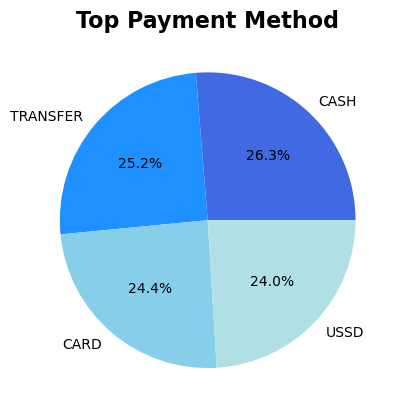

In [44]:
# Code to show the Distribution of the Payment Methods.
top_payment_rev = (
    orders.groupby("payment_method")["total_amount"]
        .sum()
        .sort_values(ascending = False)
)

top_payment_rev.plot(kind = "pie", autopct = "%1.1f%%", colors=["royalblue", "dodgerblue", "skyblue", "powderblue"])
plt.title("Top Payment Method", fontsize = 16, fontweight = "bold")
plt.ylabel("")
plt.show()

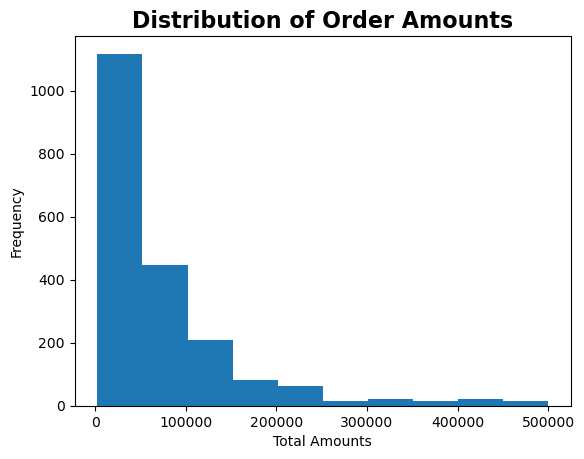

In [46]:
# Code to show the Distribution of Order Amounts.
orders["total_amount"].plot(kind = "hist")
plt.title("Distribution of Order Amounts", fontsize = 16, fontweight = "bold")
plt.xlabel("Total Amounts")
plt.show()

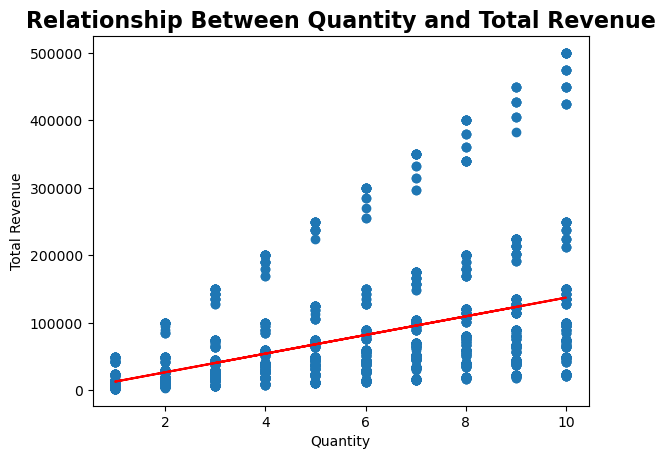

In [47]:
# Code to show the Relationship between Quantity vs Total Revenue.
x = orders["quantity"]
y = orders["total_amount"]

plt.scatter(x, y)

z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), color="red")

plt.title("Relationship Between Quantity and Total Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Quantity")
plt.ylabel("Total Revenue")
plt.show()

In [49]:
# Code to Create a Reusable Function that Returns the Top N Products by Revenue..
def top_product(n):
    result = (
        orders.merge(products, on = "product_id")
            .groupby("product_name")["total_amount"]
            .sum()
            .sort_values(ascending = False)
            .head(n)
            .rename(f"Top {n} products")
    )
    return result
    
top_product(5)

product_name
Product_36    6347500
Product_85    6200000
Product_55    5990000
Product_14    5502500
Product_81    5182500
Name: Top 5 products, dtype: int64